In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, recall_score, precision_score, classification_report, confusion_matrix, roc_auc_score)
import time

<h1>STAGE-1<h1>

In [40]:
df=pd.read_csv("C:/Users/KAVYA/Downloads/dataset_phishing.csv")
print(df.shape)


(11430, 89)


88 features + 1 target column called status.

In [41]:
print(df['status'].value_counts())

status
legitimate    5715
phishing      5715
Name: count, dtype: int64


The dataset is perfectly 50-50 balanced.
In real life, phishing URLs are NOT 50% of all URLs.
On the internet, maybe 1-2% of URLs are phishing. So this dataset is artificially balanced.
Our model is going to learn from a world where phishing is 50% common. But it will be deployed in a world where phishing is 2% common. This is called distribution shift and it's a real research problem.

In [42]:
df.head()

,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate


In [43]:
# What types of values do our features have?
print(df.dtypes.value_counts())

int64      74
float64    13
str         2
Name: count, dtype: int64


In [44]:
# Are there any missing values?
print("Missing values : ",df.isnull().sum().sum())

Missing values :  0


In [45]:
print(df.columns.tolist())

['url', 'length_url', 'length_hostname', 'ip', 'nb_dots', 'nb_hyphens', 'nb_at', 'nb_qm', 'nb_and', 'nb_or', 'nb_eq', 'nb_underscore', 'nb_tilde', 'nb_percent', 'nb_slash', 'nb_star', 'nb_colon', 'nb_comma', 'nb_semicolumn', 'nb_dollar', 'nb_space', 'nb_www', 'nb_com', 'nb_dslash', 'http_in_path', 'https_token', 'ratio_digits_url', 'ratio_digits_host', 'punycode', 'port', 'tld_in_path', 'tld_in_subdomain', 'abnormal_subdomain', 'nb_subdomains', 'prefix_suffix', 'random_domain', 'shortening_service', 'path_extension', 'nb_redirection', 'nb_external_redirection', 'length_words_raw', 'char_repeat', 'shortest_words_raw', 'shortest_word_host', 'shortest_word_path', 'longest_words_raw', 'longest_word_host', 'longest_word_path', 'avg_words_raw', 'avg_word_host', 'avg_word_path', 'phish_hints', 'domain_in_brand', 'brand_in_subdomain', 'brand_in_path', 'suspecious_tld', 'statistical_report', 'nb_hyperlinks', 'ratio_intHyperlinks', 'ratio_extHyperlinks', 'ratio_nullHyperlinks', 'nb_extCSS', 'rat

In [46]:
print("Max URL length in dataset:", df['length_url'].max())
print("Min URL length in dataset:", df['length_url'].min())
print("URLs over 2000 chars:", (df['length_url'] > 2000).sum())

Max URL length in dataset: 1641
Min URL length in dataset: 12
URLs over 2000 chars: 0


In [47]:
# Find the longest URL in our dataset — what does it look like?
longest_idx = df['length_url'].idxmax()
print("Longest URL:")
print(df.loc[longest_idx, 'url'])
print("\nIs it phishing?", df.loc[longest_idx, 'status'])

Longest URL:
https://dev.seatassignmate.net/latam/payment_onsite.php?data=OSJDiYvam7d2RdxBW6THtDnUSa386QBYQsC-YwclMVm8LSB47xP0KqlfoUSy7HwxZXHYfOJIuLss7Ja6pBQp40Ai7J-G2z1PnlajIVIwGEuiNWWlN5cowtkXv2KUfEkICym6Fp7HA3PAiakjTnRbWiH8iIBtQEAeuaIKxTFGos6sXUH9Vp7vBecr61ZCHGzTuSRm/NNXT-B7rQzYbZVhjkgLu-l6VKXfrHSg3QYh4x-rTQRALU9sjsVXoA2dYQf1paXOI6tv-KfZUVeHjC8wt7BrEPTefftPqzD7PLqWNtWrSt95pcgZ8DpQxbB0TwufbVxGM3ATv9O-6zpA2rst9H1JK5o327bNpZxiFRK0aozBO5JRcgmXDtReSEMC4cFuYS53Uv6KjhYVRZr6JxocUJfM9qJELpnjzTmqy9aqkjZAJJN-y0UzXTF7l/t8-B6tfq-/CQZGNe7giGvkz65oPJAF42tgLRm/NTT6nYO6wBNxBke84ydu75V6X1E6jwb3BLPk-VflwZ1q/qFaKJWXU0Aj8J9qDR/FHhKFhi/3q3MTnsjVLnJEweDaVKbhXT55UazUwZpX01H3QoUu2KS-9-sc4xFkY-CS16pqCpcbo3MchIxgJaMDZoK3zoUkhPYmH/PZ0L3oCENsib7eWrXpqMIDHnYBlhNEAkbLofw/EUnmu1m/kR-IANwkHTnG8vjE3RAtptQAjxOs61bU0S6ZTnUvTYBD4a86/Pmp20vo5xHFiHZGrABqv3uq-81pyj61C0Ru7UJ1fWdualOXOfWn-4RXptUKWAu6KHtCPMa3YSonYvn72ELNFUT1DVM7A7mA/NDikA/cZlx-nhMDS7BBXVSDczZN7ykk/3/nOsV67tS34E3WBYCITxTwB85L5-6CoJe/fylby-9/yL-RD75mBT3akWJQyT

In [48]:
# How many URLs use http vs https?
df['scheme'] = df['url'].apply(lambda x: x.split('://')[0] if '://' in x else 'unknown')
print("Scheme distribution:")
print(df.groupby(['scheme', 'status']).size())


scheme_pct = df.groupby('scheme')['status'].value_counts(normalize=True) * 100
print(scheme_pct)

Scheme distribution:
scheme  status    
http    legitimate    3172
        phishing      3811
https   legitimate    2543
        phishing      1904
dtype: int64
scheme  status    
http    phishing      54.575397
        legitimate    45.424603
https   legitimate    57.184619
        phishing      42.815381
Name: proportion, dtype: float64


https gives you a SLIGHT safety advantage : 57% of https URLs are legitimate vs 43% phishing. 
But that's barely better than a coin flip for phishing detection. 
If you built a model that ONLY used the scheme to decide, it would be wrong 43% of the time on https URLs.
This is why https_token alone is a weak feature.

In [49]:
for feat in ['phish_hints', 'ip', 'shortening_service', 'prefix_suffix']:
    total = df.groupby(feat)['status'].value_counts()
    pct   = df.groupby(feat)['status'].value_counts(normalize=True) * 100
    print(f"\n── {feat} ──")
    print(pct.round(1))


── phish_hints ──
phish_hints  status    
0            legitimate     58.5
             phishing       41.5
1            phishing       81.6
             legitimate     18.4
2            phishing       94.8
             legitimate      5.2
3            phishing       98.8
             legitimate      1.2
4            phishing      100.0
5            phishing      100.0
6            phishing      100.0
7            phishing      100.0
10           phishing      100.0
Name: proportion, dtype: float64

── ip ──
ip  status    
0   legitimate    56.8
    phishing      43.2
1   phishing      88.2
    legitimate    11.8
Name: proportion, dtype: float64

── shortening_service ──
shortening_service  status    
0                   legitimate    52.0
                    phishing      48.0
1                   phishing      64.1
                    legitimate    35.9
Name: proportion, dtype: float64

── prefix_suffix ──
prefix_suffix  status    
0              legitimate    55.4
               phi

In [50]:
df['label'] = (df['status'] == 'phishing').astype(int)
numeric_df = df.drop(['url', 'status', 'scheme'], axis=1)

correlations = numeric_df.corr()['label'].drop('label')
correlations_sorted = correlations.abs().sort_values(ascending=False)

print("Top 20 features most correlated with phishing:")
print(correlations_sorted.head(20).to_string())

Top 20 features most correlated with phishing:
google_index           0.731171
page_rank              0.511137
nb_www                 0.443468
ratio_digits_url       0.356395
domain_in_title        0.342807
nb_hyperlinks          0.342628
phish_hints            0.335393
domain_age             0.331889
ip                     0.321698
nb_qm                  0.294319
length_url             0.248580
ratio_intHyperlinks    0.243982
nb_slash               0.242270
length_hostname        0.238322
nb_eq                  0.233386
ratio_digits_host      0.224335
shortest_word_host     0.223084
prefix_suffix          0.214681
longest_word_path      0.212709
tld_in_subdomain       0.208884


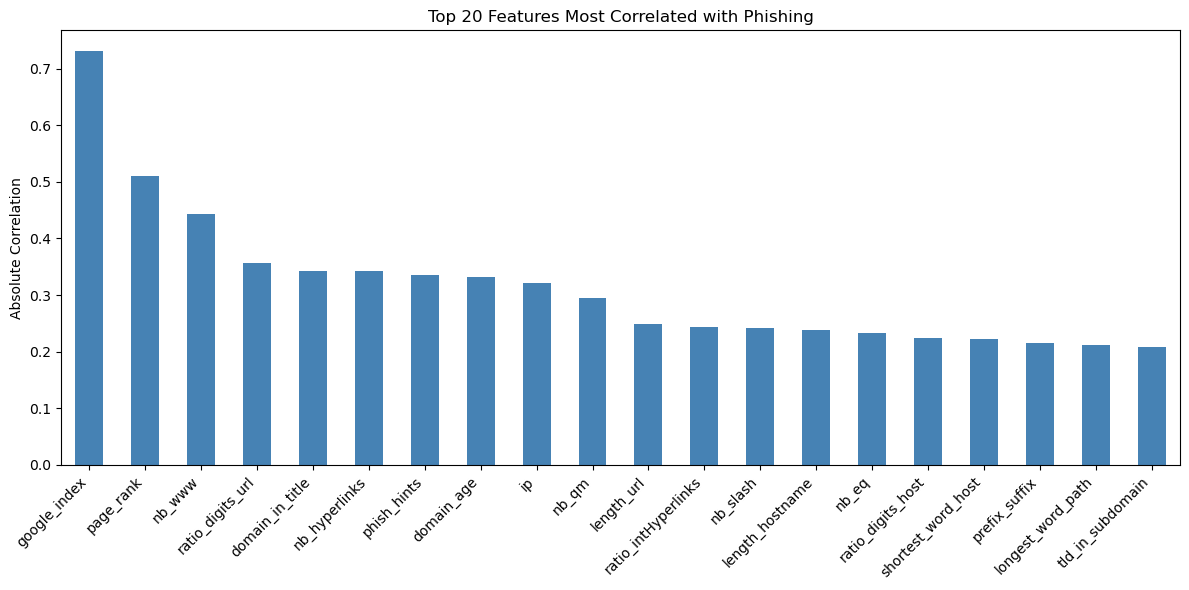

In [51]:
plt.figure(figsize=(12, 6))
correlations_sorted.head(20).plot(kind='bar', color='steelblue')
plt.title('Top 20 Features Most Correlated with Phishing')
plt.ylabel('Absolute Correlation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [84]:
X=df.drop(['url','status','label','scheme'],axis=1)
y=df['label']
print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Features used: {X.columns.tolist()}")

Feature matrix shape: (11430, 87)
Target shape: (11430,)
Features used: ['length_url', 'length_hostname', 'ip', 'nb_dots', 'nb_hyphens', 'nb_at', 'nb_qm', 'nb_and', 'nb_or', 'nb_eq', 'nb_underscore', 'nb_tilde', 'nb_percent', 'nb_slash', 'nb_star', 'nb_colon', 'nb_comma', 'nb_semicolumn', 'nb_dollar', 'nb_space', 'nb_www', 'nb_com', 'nb_dslash', 'http_in_path', 'https_token', 'ratio_digits_url', 'ratio_digits_host', 'punycode', 'port', 'tld_in_path', 'tld_in_subdomain', 'abnormal_subdomain', 'nb_subdomains', 'prefix_suffix', 'random_domain', 'shortening_service', 'path_extension', 'nb_redirection', 'nb_external_redirection', 'length_words_raw', 'char_repeat', 'shortest_words_raw', 'shortest_word_host', 'shortest_word_path', 'longest_words_raw', 'longest_word_host', 'longest_word_path', 'avg_words_raw', 'avg_word_host', 'avg_word_path', 'phish_hints', 'domain_in_brand', 'brand_in_subdomain', 'brand_in_path', 'suspecious_tld', 'statistical_report', 'nb_hyperlinks', 'ratio_intHyperlinks',

In [85]:
print(df.groupby(['punycode','status']).size())

punycode  status    
0         legitimate    5715
          phishing      5711
1         phishing         4
dtype: int64


In [86]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20, random_state=42, stratify=y)
print(f"Training set: {X_train.shape}")
print(f"Test seet: {X_test.shape}")
print(f"Train phishing: {y_train.mean()*100:.1f}%")
print(f"Test phishing: {y_test.mean()*100:.1f}%")

Training set: (9144, 87)
Test seet: (2286, 87)
Train phishing: 50.0%
Test phishing: 50.0%


In [87]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
print(f"Train mean (should be ~0): {X_train_scaled.mean():.4f}")
print(f"Train std (should be ~1): {X_train_scaled.std():.4f}")
print(f"Test mean (will not be exactly 0): {X_test_scaled.mean():.4f}")

Train mean (should be ~0): 0.0000
Train std (should be ~1): 0.9649
Test mean (will not be exactly 0): 0.0066


In [88]:
print("Training Logistic Regression")
start=time.time()
lr=LogisticRegression(max_iter=100, random_state=42)
lr.fit(X_train_scaled,y_train)
print(f"Done in {time.time()-start:.1f}s")
print(f"Converged: {lr.n_iter_} iterations")

Training Logistic Regression
Done in 0.2s
Converged: [61] iterations


In [89]:
lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:,1]

print("LOGISTIC REGRESSION RESULTS")
print(f"Accuracy: {accuracy_score(y_test, lr_pred)*100:.2f}%")
print(f"AUC: {roc_auc_score(y_test, lr_prob):.4f}")
print("\nClassification Report: ")
print(classification_report(y_test, lr_pred, target_names=['Legistimate','Phishing']))

LOGISTIC REGRESSION RESULTS
Accuracy: 93.61%
AUC: 0.9814

Classification Report: 
              precision    recall  f1-score   support

 Legistimate       0.93      0.94      0.94      1143
    Phishing       0.94      0.93      0.94      1143

    accuracy                           0.94      2286
   macro avg       0.94      0.94      0.94      2286
weighted avg       0.94      0.94      0.94      2286



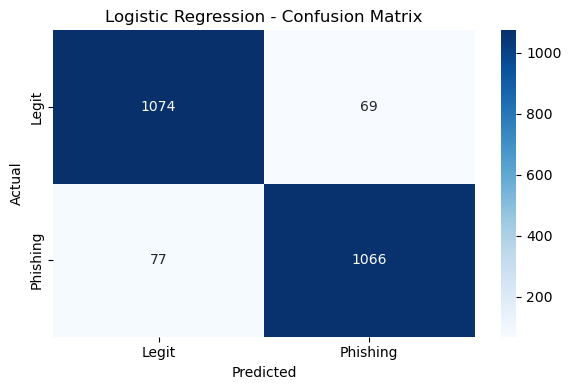

In [90]:
cm = confusion_matrix(y_test, lr_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['Legit','Phishing'],yticklabels=['Legit','Phishing'])
plt.title('Logistic Regression - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [91]:
print("Training Random Forest")
start=time.time()
rf=RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)
rf.fit(X_train,y_train)
print(f"Done in {time.time()-start:.1f}s")
print(f"Trees built: {len(rf.estimators_)}")

Training Random Forest
Done in 1.3s
Trees built: 100


In [92]:
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]

print("RANDOM FOREST RESULTS")
print(f"Accuracy: {accuracy_score(y_test, rf_pred)*100:.2f}%")
print(f"AUC: {roc_auc_score(y_test, rf_prob):.4f}")
print("\nClassification Report: ")
print(classification_report(y_test, rf_pred, target_names=['Legistimate','Phishing']))

RANDOM FOREST RESULTS
Accuracy: 95.93%
AUC: 0.9935

Classification Report: 
              precision    recall  f1-score   support

 Legistimate       0.96      0.95      0.96      1143
    Phishing       0.95      0.96      0.96      1143

    accuracy                           0.96      2286
   macro avg       0.96      0.96      0.96      2286
weighted avg       0.96      0.96      0.96      2286



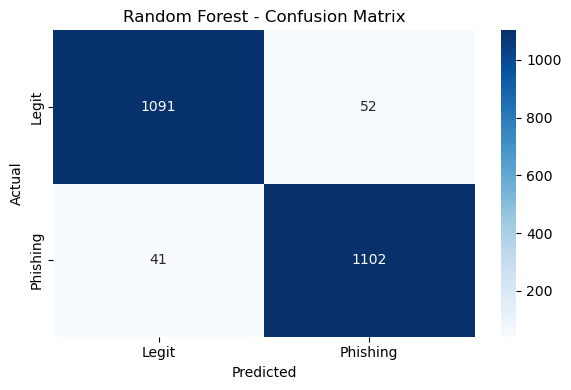

In [93]:
cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['Legit','Phishing'],yticklabels=['Legit','Phishing'])
plt.title('Random Forest - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

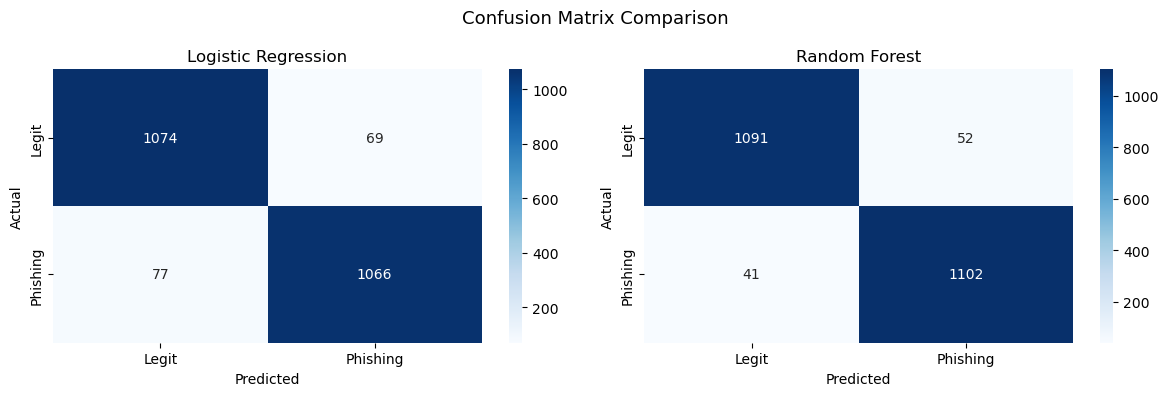

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, name, pred in [
    (axes[0], "Logistic Regression", lr_pred),
    (axes[1], "Random Forest",       rf_pred)
]:
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Legit','Phishing'],
                yticklabels=['Legit','Phishing'])
    ax.set_title(f'{name}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrix Comparison', fontsize=13)
plt.tight_layout()
plt.show()

In [95]:
thresholds=np.arange(0.1,0.95,0.05)
recalls     = []
precisions  = []
fprs        = []
accuracies  = []
for t in thresholds:
    preds = (rf_prob >= t).astype(int)
    recalls.append(recall_score(y_test, preds))
    precisions.append(precision_score(y_test, preds, zero_division=0))
    accuracies.append(accuracy_score(y_test, preds))
    cm  = confusion_matrix(y_test, preds)
    fprs.append(cm[0,1] / (cm[0,0] + cm[0,1]))

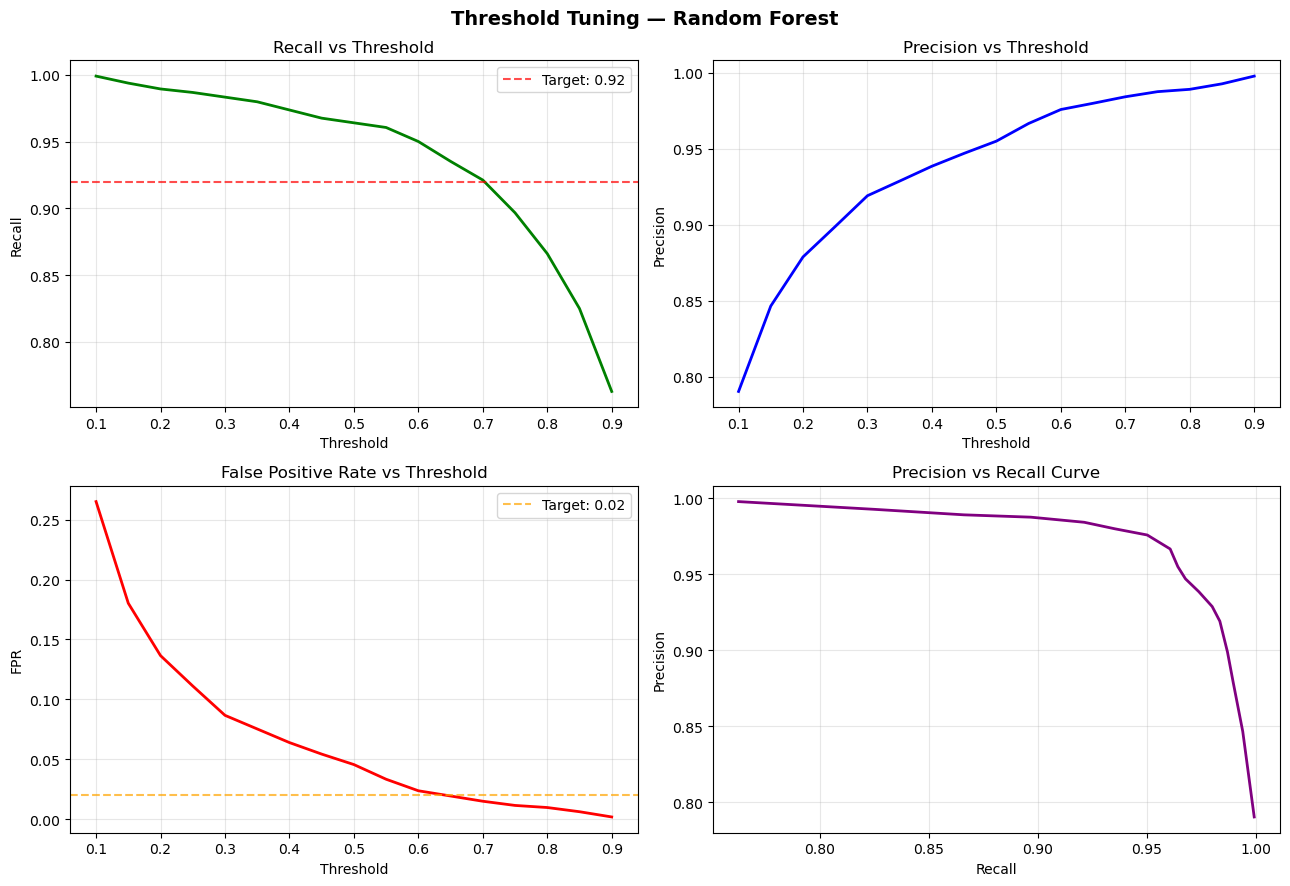

In [96]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Threshold Tuning — Random Forest', fontsize=14, fontweight='bold')

# Plot 1 - Recall
axes[0,0].plot(thresholds, recalls, color='green', linewidth=2)
axes[0,0].axhline(y=0.92, color='red', linestyle='--', alpha=0.7, label='Target: 0.92')
axes[0,0].set_title('Recall vs Threshold')
axes[0,0].set_xlabel('Threshold')
axes[0,0].set_ylabel('Recall')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Plot 2 - Precision
axes[0,1].plot(thresholds, precisions, color='blue', linewidth=2)
axes[0,1].set_title('Precision vs Threshold')
axes[0,1].set_xlabel('Threshold')
axes[0,1].set_ylabel('Precision')
axes[0,1].grid(True, alpha=0.3)

# Plot 3 - FPR
axes[1,0].plot(thresholds, fprs, color='red', linewidth=2)
axes[1,0].axhline(y=0.02, color='orange', linestyle='--', alpha=0.7, label='Target: 0.02')
axes[1,0].set_title('False Positive Rate vs Threshold')
axes[1,0].set_xlabel('Threshold')
axes[1,0].set_ylabel('FPR')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Plot 4 - Precision vs Recall tradeoff
axes[1,1].plot(recalls, precisions, color='purple', linewidth=2)
axes[1,1].set_title('Precision vs Recall Curve')
axes[1,1].set_xlabel('Recall')
axes[1,1].set_ylabel('Precision')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [97]:
best_threshold = None
best_recall = 0

for i, t in enumerate(thresholds):
    if recalls[i] >= 0.92 and fprs[i] <= 0.02:
        if recalls[i] > best_recall:
            best_recall = recalls[i]
            best_threshold = t

print(f"Optimal threshold: {best_threshold:.2f}")
print(f"Recall at optimal: {best_recall:.4f}")
print(f"FPR at optimal:    {fprs[list(thresholds).index(best_threshold)]:.4f}")
print(f"Precision:         {precisions[list(thresholds).index(best_threshold)]:.4f}")

Optimal threshold: 0.65
Recall at optimal: 0.9353
FPR at optimal:    0.0192
Precision:         0.9798


RANDOM FOREST — TUNED THRESHOLD (0.65)

Threshold:  0.65
Recall:     0.9379
Precision:  0.9781
Accuracy:   0.9584
AUC:        0.9935

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.94      0.98      0.96      1143
    Phishing       0.98      0.94      0.96      1143

    accuracy                           0.96      2286
   macro avg       0.96      0.96      0.96      2286
weighted avg       0.96      0.96      0.96      2286



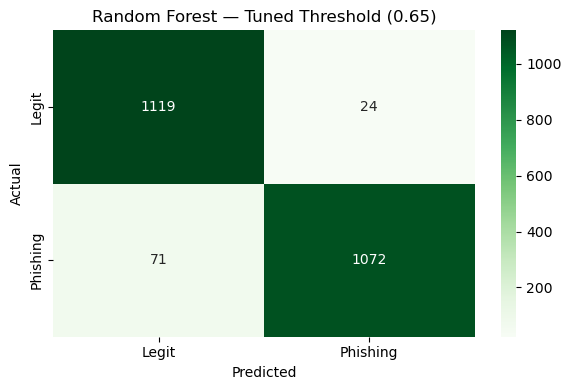

In [98]:

BEST_THRESHOLD = 0.65

# Apply tuned threshold
rf_pred_tuned = (rf_prob >= BEST_THRESHOLD).astype(int)

print("RANDOM FOREST — TUNED THRESHOLD (0.65)\n")
print(f"Threshold:  {BEST_THRESHOLD}")
print(f"Recall:     {recall_score(y_test, rf_pred_tuned):.4f}")
print(f"Precision:  {precision_score(y_test, rf_pred_tuned):.4f}")
print(f"Accuracy:   {accuracy_score(y_test, rf_pred_tuned):.4f}")
print(f"AUC:        {roc_auc_score(y_test, rf_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred_tuned,
      target_names=['Legitimate', 'Phishing']))

# Confusion matrix
cm = confusion_matrix(y_test, rf_pred_tuned)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Legit', 'Phishing'],
            yticklabels=['Legit', 'Phishing'])
plt.title(f'Random Forest — Tuned Threshold ({BEST_THRESHOLD})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

<h2>STAGE-2</h2>

In [99]:
import pandas as pd
import matplotlib.pyplot as plt

importances = rf.feature_importances_
feat_names  = X.columns

feat_df = pd.DataFrame({
    'feature':    feat_names,
    'importance': importances
}).sort_values('importance', ascending=False).reset_index(drop=True)

feat_df.index += 1  

print("## Random Forest — Feature Importance Rankings\n")
print(f"{'Rank':<6} {'Feature':<35} {'Importance':>12} {'Cumulative':>12}")
print("-" * 68)

cumulative = 0
for idx, row in feat_df.head(20).iterrows():
    cumulative += row['importance']
    print(f"{idx:<6} {row['feature']:<35} {row['importance']:>12.4f} {cumulative:>12.4f}")

print("-" * 68)
print(f"\nTop 5  features explain: {feat_df.head(5)['importance'].sum()*100:.1f}% of model decisions")
print(f"Top 10 features explain: {feat_df.head(10)['importance'].sum()*100:.1f}% of model decisions")
print(f"Top 20 features explain: {feat_df.head(20)['importance'].sum()*100:.1f}% of model decisions")
print(f"\nTotal features:          {len(feat_df)}")
print(f"Near-zero importance:    {(feat_df['importance'] < 0.001).sum()} features")

## Random Forest — Feature Importance Rankings

Rank   Feature                               Importance   Cumulative
--------------------------------------------------------------------
1      google_index                              0.1810       0.1810
2      page_rank                                 0.0988       0.2797
3      nb_hyperlinks                             0.0891       0.3688
4      web_traffic                               0.0732       0.4420
5      nb_www                                    0.0418       0.4838
6      domain_age                                0.0334       0.5172
7      phish_hints                               0.0308       0.5480
8      ratio_extHyperlinks                       0.0282       0.5762
9      ratio_intHyperlinks                       0.0250       0.6012
10     safe_anchor                               0.0245       0.6257
11     ratio_extRedirection                      0.0230       0.6487
12     longest_word_path                         0.0219

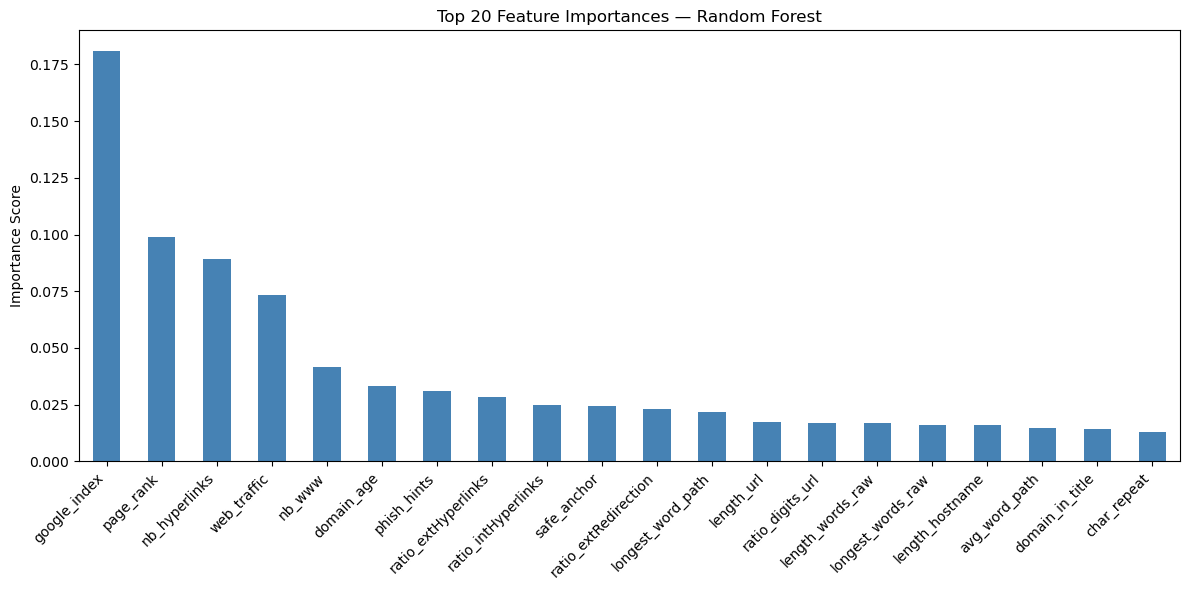

In [100]:
# Visualize top 20
plt.figure(figsize=(12, 6))
feat_df.head(20).plot(
    kind='bar', x='feature', y='importance',
    color='steelblue', legend=False, ax=plt.gca()
)
plt.title('Top 20 Feature Importances — Random Forest')
plt.ylabel('Importance Score')
plt.xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


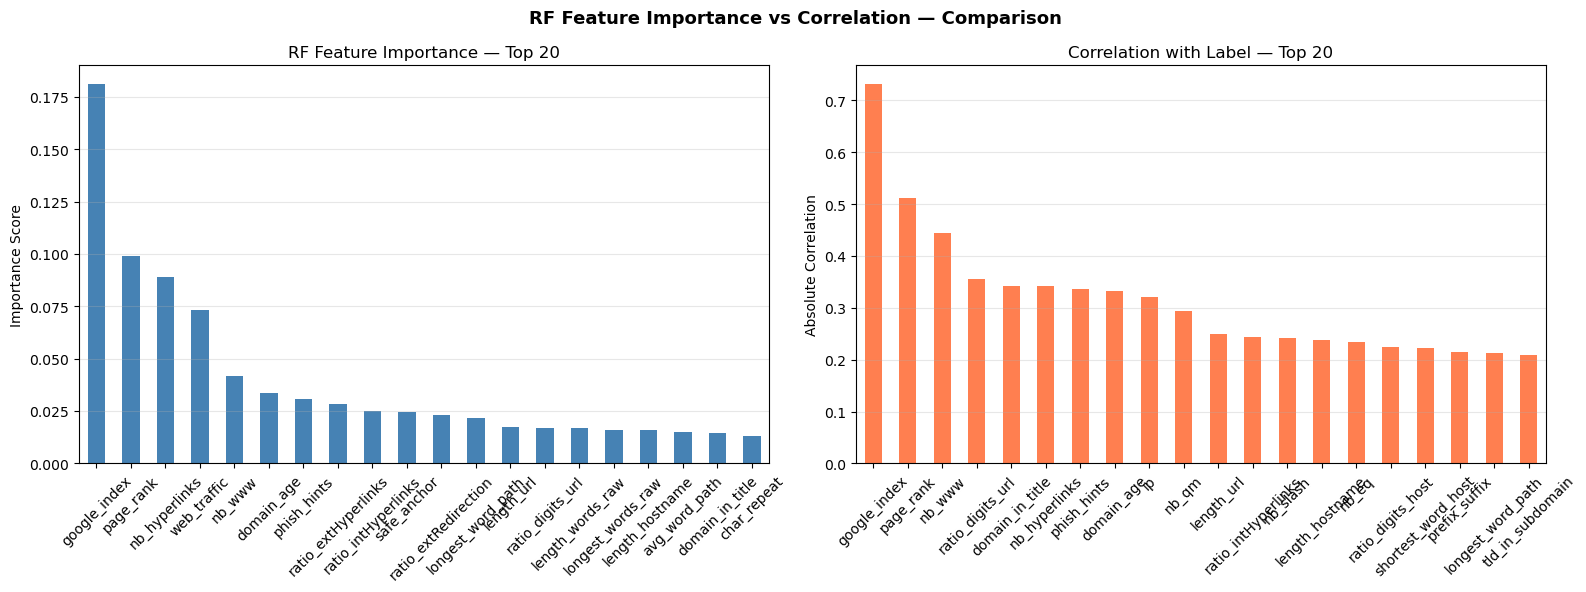

In [101]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: RF Feature Importance ──
feat_df.head(20).plot(
    kind='bar', x='feature', y='importance',
    color='steelblue', legend=False, ax=axes[0]
)
axes[0].set_title('RF Feature Importance — Top 20')
axes[0].set_ylabel('Importance Score')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# ── Right: Correlation ──
correlations_sorted.head(20).plot(
    kind='bar', color='coral', legend=False, ax=axes[1]
)
axes[1].set_title('Correlation with Label — Top 20')
axes[1].set_ylabel('Absolute Correlation')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('RF Feature Importance vs Correlation — Comparison', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [102]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# AUC across 5 folds
cv_auc = cross_val_score(
    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    X, y,
    cv=cv,
    scoring='roc_auc'
)

# Accuracy across 5 folds
cv_acc = cross_val_score(
    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    X, y,
    cv=cv,
    scoring='accuracy'
)

print("5-Fold Cross Validation Results")
print("=" * 40)
print(f"{'Fold':<8} {'AUC':>10} {'Accuracy':>10}")
print("-" * 30)
for i, (auc, acc) in enumerate(zip(cv_auc, cv_acc), 1):
    print(f"Fold {i:<4} {auc:>10.4f} {acc:>10.4f}")
print("-" * 30)
print(f"{'Mean':<8} {cv_auc.mean():>10.4f} {cv_acc.mean():>10.4f}")
print(f"{'Std':<8} {cv_auc.std():>10.4f} {cv_acc.std():>10.4f}")

5-Fold Cross Validation Results
Fold            AUC   Accuracy
------------------------------
Fold 1        0.9915     0.9598
Fold 2        0.9952     0.9724
Fold 3        0.9929     0.9633
Fold 4        0.9934     0.9720
Fold 5        0.9941     0.9659
------------------------------
Mean         0.9934     0.9667
Std          0.0012     0.0049


Mean = average AUC across all 5 folds — the honest performance estimate.

Std = standard deviation — how much the AUC varied across folds.

If std is LOW (like 0.002):

  All 5 folds gave similar AUC
  Model performs consistently
  Results are stable and trustworthy 

If std is HIGH (like 0.05):

  AUC jumped around between folds
  Model is sensitive to which data it sees
  Results might not generalise well

<h1>STAGE-3<h1>

In [103]:
from sklearn.ensemble import IsolationForest

#Training on legitimate urls
X_train_legit=X_train[y_train==0]
print(f"Training Isolation Forest on {X_train_legit.shape[0]}")
iso=IsolationForest(n_estimators=100, # 100 trees
                    contamination=0.05, # expecting 5% anomalies in training data
                    random_state=42,
                    n_jobs=-1
                   )
iso.fit(X_train_legit)

Training Isolation Forest on 4572


,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.05
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


ISOLATION FOREST RESULTS
              precision    recall  f1-score   support

  Legitimate       0.65      0.95      0.78      1143
    Phishing       0.92      0.50      0.64      1143

    accuracy                           0.73      2286
   macro avg       0.79      0.73      0.71      2286
weighted avg       0.79      0.73      0.71      2286



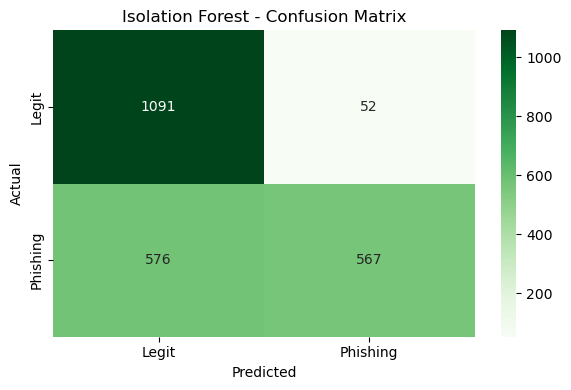

In [104]:
# Predict on test data

iso_pred_raw=iso.predict(X_test)
iso_pred=(iso_pred_raw==-1).astype(int)

print("ISOLATION FOREST RESULTS")
print(classification_report(y_test, iso_pred, target_names=['Legitimate','Phishing']))

cm=confusion_matrix(y_test,iso_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Greens',
            xticklabels=['Legit','Phishing'],
            yticklabels=['Legit','Phishing'])
plt.title('Isolation Forest - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [105]:
#Combined Prediction - flag if either model says suspicious

combined_pred =((rf_pred_tuned == 1) |(iso_pred==1)).astype(int)

print("COMBINED MODEL RESULTS")
print(f"Recall    : {recall_score(y_test,combined_pred):.4f}")
print(f"Precision : {precision_score(y_test,combined_pred):.4f}")
print(f"Accuracy  : {accuracy_score(y_test,combined_pred):.4f}")

print(f"{'Model':<25} {'Recall':>8} {'Precision':>10} {'Accuracy':>10}")
print("-" * 55)
print(f"{'Random Forest (tuned)':<25} {recall_score(y_test, rf_pred_tuned):>8.4f} {precision_score(y_test, rf_pred_tuned):>10.4f} {accuracy_score(y_test, rf_pred_tuned):>10.4f}")
print(f"{'Isolation Forest':<25} {recall_score(y_test, iso_pred):>8.4f} {precision_score(y_test, iso_pred):>10.4f} {accuracy_score(y_test, iso_pred):>10.4f}")
print(f"{'Combined (RF + IF)':<25} {recall_score(y_test, combined_pred):>8.4f} {precision_score(y_test, combined_pred):>10.4f} {accuracy_score(y_test, combined_pred):>10.4f}")

COMBINED MODEL RESULTS
Recall    : 0.9475
Precision : 0.9409
Accuracy  : 0.9440
Model                       Recall  Precision   Accuracy
-------------------------------------------------------
Random Forest (tuned)       0.9379     0.9781     0.9584
Isolation Forest            0.4961     0.9160     0.7253
Combined (RF + IF)          0.9475     0.9409     0.9440


<h2 style="color:Orange">Combined model:</h2>


+ Catches 11 more phishing URLs    ← better safety
- 43 more false alarms             ← slightly more annoying

Isolation Forest alone:   weak (50% recall)

Random Forest alone:      strong (93.8% recall)

Combined:                 strongest (94.8% recall)

<h1>STAGE-4</h1>

In [106]:
import shap
print(shap.__version__)

#SHapley Additive exPlanations

0.51.0


In [107]:
print("Creating SHAP explainer..")
explainer=shap.TreeExplainer(rf)
print("Created")

Creating SHAP explainer..
Created


<h3>NOTE:</h3>
RF model looks at a URL and says "92% phishing." But WHY? Which of the 87 features pushed it toward that decision?

SHAP answers exactly that — for every single prediction, it tells:

URL: http://paypal-secure-login.xyz/verify

Model says: 92% phishing

<h5 style="color:red">WHY?</h5>

google_index = 0    pushed toward phishing by +0.34

domain_age   = 3    pushed toward phishing by +0.28

phish_hints  = 2    pushed toward phishing by +0.21

page_rank    = 0    pushed toward phishing by +0.19

nb_www       = 2    pushed toward phishing by +0.08

length_url   = 45   pushed toward legit    by -0.05



==>shap_values returns two arrays:

shap_values[0]  →  SHAP values for class 0 (legitimate)

shap_values[1]  →  SHAP values for class 1 (phishing)

In [109]:
X_test_sample = X_test.iloc[:500]
shap_values   = explainer.shap_values(X_test_sample)
# Check the actual array structure
print(f"shap_values full shape: {np.array(shap_values).shape}")

# For binary classification RF, shap_values is sometimes
# shaped as (n_samples, n_features, n_classes)

shap_array = np.array(shap_values)
print(f"shap_array shape: {shap_array.shape}")

# Extract phishing class (class 1) SHAP values
if len(shap_array.shape) == 3:
    # shape is (n_samples, n_features, n_classes)
    shap_phishing = shap_array[:, :, 1]
    print(f"Extracted phishing SHAP values: {shap_phishing.shape}")
elif len(shap_array.shape) == 2:
    shap_phishing = shap_array
    print(f"Already correct shape: {shap_phishing.shape}")

print(f"\nFinal shape: {shap_phishing.shape}")
print(f"Rows (URLs):     {shap_phishing.shape[0]}")
print(f"Cols (features): {shap_phishing.shape[1]}")

shap_values full shape: (500, 87, 2)
shap_array shape: (500, 87, 2)
Extracted phishing SHAP values: (500, 87)

Final shape: (500, 87)
Rows (URLs):     500
Cols (features): 87


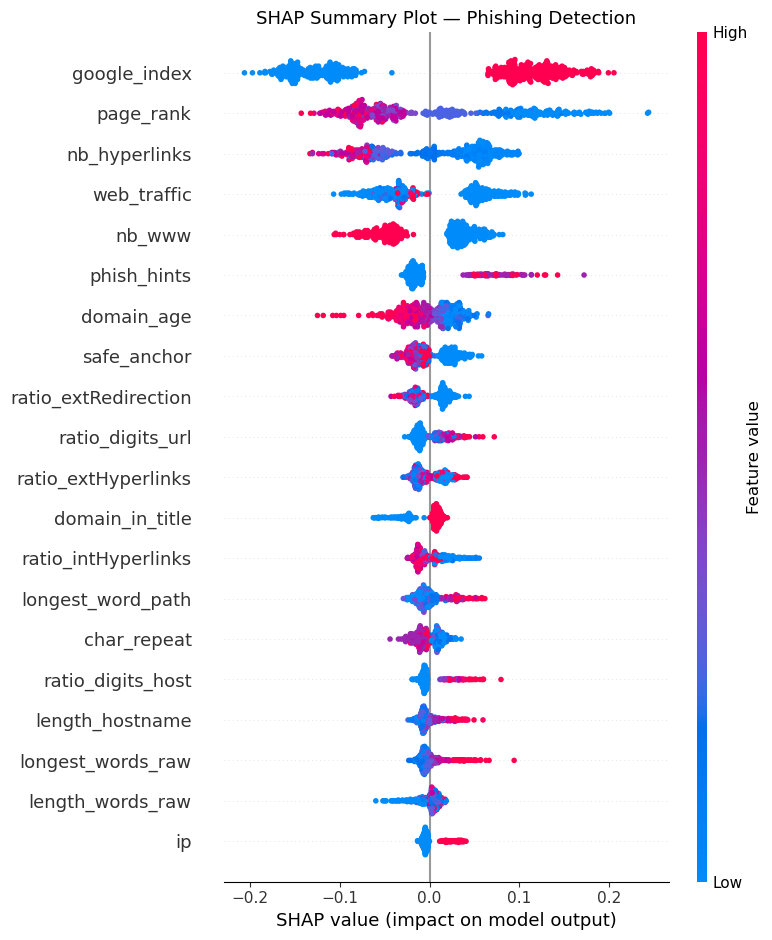

In [110]:
plt.figure()
shap.summary_plot(
    shap_phishing,
    X_test_sample,
    feature_names=X.columns.tolist(),
    show=False
)
plt.title("SHAP Summary Plot — Phishing Detection", fontsize=13)
plt.tight_layout()
plt.show()

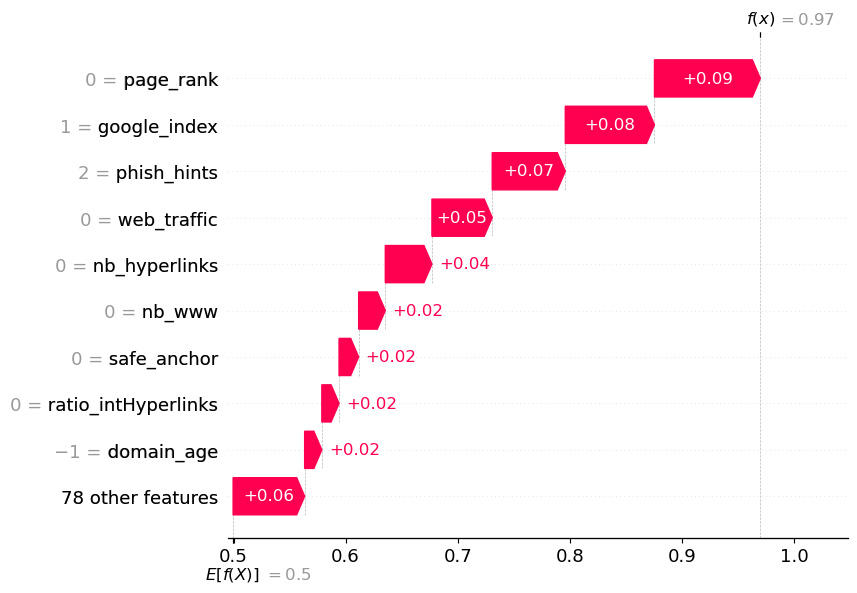

In [111]:

phishing_indices = X_test_sample[y_test.iloc[:500].values == 1].index
first_phishing   = X_test_sample.index.get_loc(phishing_indices[0])

shap.waterfall_plot(
    shap.Explanation(
        values        = shap_phishing[first_phishing],
        base_values   = explainer.expected_value[1],
        data          = X_test_sample.iloc[first_phishing],
        feature_names = X.columns.tolist()
    )
)

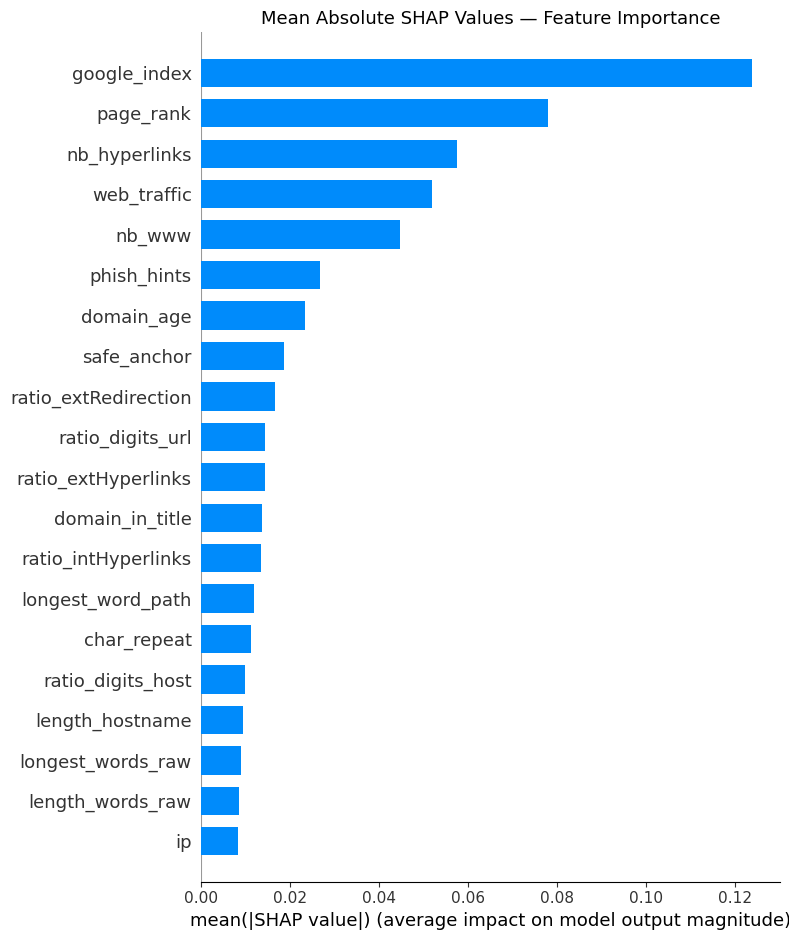

In [112]:
# Mean absolute SHAP 
shap.summary_plot(
    shap_phishing,
    X_test_sample,
    feature_names = X.columns.tolist(),
    plot_type     = "bar",
    show          = False
)
plt.title("Mean Absolute SHAP Values — Feature Importance", fontsize=13)
plt.tight_layout()
plt.show()

In [80]:
import joblib
import os

#Create a models folder
os.makedirs('models',exist_ok=True)

#Save Random Forest model
joblib.dump(rf,'models/rf_model.pkl')

#Save the scaler 
joblib.dump(scaler,'models/scaler.pkl')

#Save Isolation Forest
joblib.dump(iso,'models/iso_model.pkl')

print("Models saved:")
print(" models/rf_model.pkl")
print(" models/scaler.pkl")
print(" models/iso_model.pkl")

Models saved:
 models/rf_model.pkl
 models/scaler.pkl
 models/iso_model.pkl


In [81]:
#saving features in exact order

feature_names=X.columns.tolist()

import json
with open('models/feature_names.json','w') as f:
    json.dump(feature_names,f)
print(f"Saved {len(feature_names)} feature names")
print("First 5:", feature_names[:5])
print("Last 5:",feature_names[-5:])


Saved 87 feature names
First 5: ['length_url', 'length_hostname', 'ip', 'nb_dots', 'nb_hyphens']
Last 5: ['domain_age', 'web_traffic', 'dns_record', 'google_index', 'page_rank']


In [82]:
import json

metadata = {
    'optimal_threshold':  0.65,
    'model_type':         'RandomForest',
    'n_estimators':       100,
    'n_features':         87,
    'auc':                0.9935,
    'recall':             0.9379,
    'precision':          0.9781,
    'accuracy':           0.9584,
    'fpr':                0.0192,
    'cv_mean_auc':        0.9934,
    'cv_std_auc':         0.0012,
    'dataset_size':       11430,
    'top_features':       ['google_index', 'page_rank',
                           'nb_www', 'phish_hints', 'domain_age']
}

with open('models/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Metadata saved successfully")

Metadata saved successfully


In [83]:

import joblib

rf_loaded  = joblib.load('models/rf_model.pkl')
iso_loaded = joblib.load('models/iso_model.pkl')

test_url   = X_test.iloc[[0]]
pred_prob  = rf_loaded.predict_proba(test_url)[0][1]
pred_label = (pred_prob >= 0.65).astype(int)

print("Load verification passed!")
print(f"Test prediction: {pred_prob:.4f} → {'Phishing' if pred_label else 'Legitimate'}")
print(f"Actual label:    {'Phishing' if y_test.iloc[0] == 1 else 'Legitimate'}")

Load verification passed!
Test prediction: 0.9700 → Phishing
Actual label:    Phishing
